<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/10_Wasserstein_GAN_with_Gradient_Penalty_(WGAN_GP)_for_Stable_Image_Synthesis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
batch_size = 64
latent_dim = 100
learning_rate = 0.0002
epochs = 5

critic_iterations = 5
lambda_gp = 10

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Training Images:", len(train_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.07MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]

Training Images: 60000


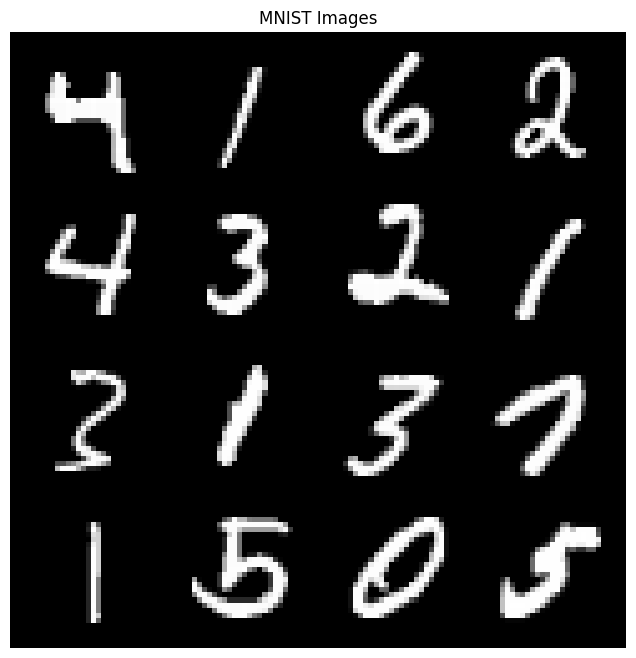

In [6]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8,8))

grid = make_grid(images[:16], nrow=4, normalize=True)

plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("MNIST Images")
plt.show()

In [7]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim,256),
            nn.ReLU(True),

            nn.Linear(256,512),
            nn.ReLU(True),

            nn.Linear(512,1024),
            nn.ReLU(True),

            nn.Linear(1024,784),
            nn.Tanh()

        )

    def forward(self,z):

        img=self.model(z)

        img=img.view(-1,1,28,28)

        return img

In [8]:
class Critic(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784,1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1)

        )

    def forward(self,img):

        img = img.view(img.size(0),-1)

        return self.model(img)

In [9]:
generator = Generator().to(device)
critic = Critic().to(device)

print(generator)
print()
print(critic)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

Critic(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)
